In [3]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import linregress

In [33]:
ticker = '^NSEI'

data = yf.download(ticker, start='2022-01-01', end='2026-03-03')

#  Fix multi-index columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

print("After download:", data.shape)
print(data.head())

# Check if empty
if data.empty:
    raise ValueError("Data download failed — try again or change ticker")

# Use Close (since Adj Close may not exist)
price = data['Adj Close'] if 'Adj Close' in data.columns else data['Close']

/tmp/ipykernel_3210/3599425899.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2022-01-01', end='2026-03-03')
[*********************100%***********************]  1 of 1 completed

After download: (1029, 5)
Price              Close          High           Low          Open  Volume
Date                                                                      
2022-01-03  17625.699219  17646.650391  17383.300781  17387.150391  200500
2022-01-04  17805.250000  17827.599609  17593.550781  17681.400391  247400
2022-01-05  17925.250000  17944.699219  17748.849609  17820.099609  251500
2022-01-06  17745.900391  17797.949219  17655.550781  17768.500000  236500
2022-01-07  17812.699219  17905.000000  17704.550781  17797.599609  239300


In [34]:
# Returns
data['Return'] = price.pct_change()

# Volatility (better window)
data['Realized Vol'] = data['Return'].rolling(5).std()
data['Prev Vol'] = data['Realized Vol'].shift(1)

# Clean
data = data[['Realized Vol', 'Prev Vol']].dropna()

print("Clean data:", data.shape)

# Regression
slope, intercept, r_value, p_value, std_err = linregress(
    data['Prev Vol'], data['Realized Vol']
)

print(f"Slope: {slope:.5f}")
print(f"R^2: {r_value**2:.5f}")

Clean data: (1023, 2)
Slope: 0.85765
R^2: 0.73561


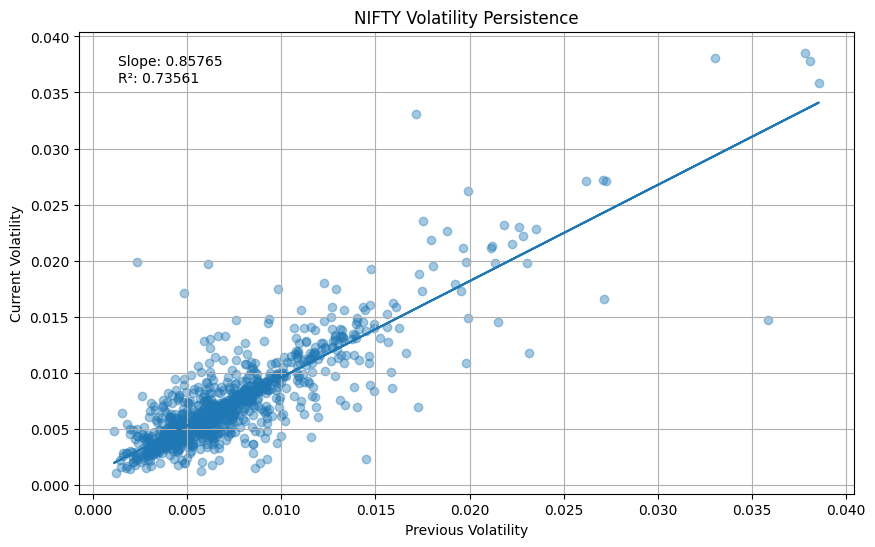

→ Higher previous-day volatility tends to lead to higher current volatility.
→ Points clustering along a line shows strong persistence (volatility clustering).
→ Slope close to 1 indicates shocks in volatility decay slowly over time.



In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(data['Prev Vol'], data['Realized Vol'], alpha=0.4)

trend = slope * data['Prev Vol'] + intercept
plt.plot(data['Prev Vol'], trend)

plt.title("NIFTY Volatility Persistence")
plt.xlabel("Previous Volatility")
plt.ylabel("Current Volatility")

# Stats on plot
plt.text(
    0.05, 0.95,
    f"Slope: {slope:.5f}\nR²: {r_value**2:.5f}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.grid(True)
plt.show()

print("→ Higher previous-day volatility tends to lead to higher current volatility.")
print("→ Points clustering along a line shows strong persistence (volatility clustering).")
print("→ Slope close to 1 indicates shocks in volatility decay slowly over time.\n")

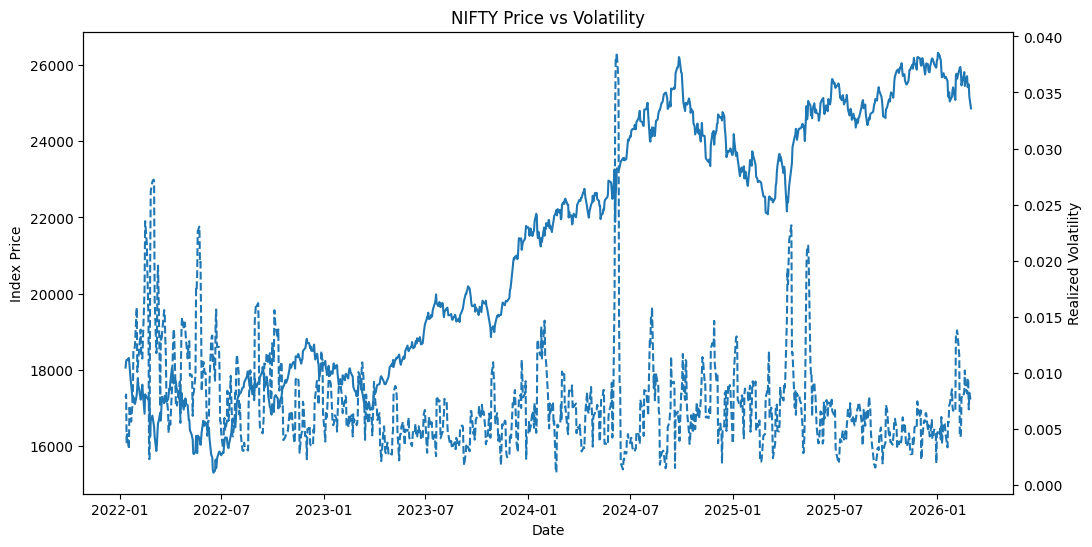

→ Volatility spikes typically occur during sharp price movements or market stress.
→ Stable price trends correspond to lower volatility regimes.
→ Shows inverse intuition: calm markets vs turbulent markets.



In [36]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.set_xlabel("Date")
ax1.set_ylabel("Index Price")
ax1.plot(data.index, price.loc[data.index])

ax2 = ax1.twinx()
ax2.set_ylabel("Realized Volatility")
ax2.plot(data.index, data['Realized Vol'], linestyle='--')

plt.title("NIFTY Price vs Volatility")
plt.show()

print("→ Volatility spikes typically occur during sharp price movements or market stress.")
print("→ Stable price trends correspond to lower volatility regimes.")
print("→ Shows inverse intuition: calm markets vs turbulent markets.\n")

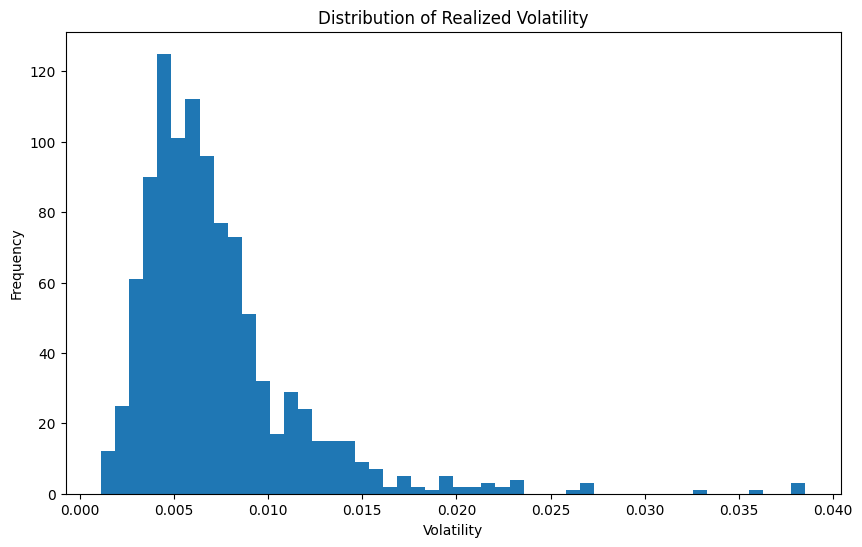

→ Most volatility observations are low, with occasional extreme spikes.
→ Right-skewed shape indicates rare but large volatility events (fat tails).
→ Confirms that volatility is not normally distributed.



In [39]:
plt.figure(figsize=(10,6))
plt.hist(data['Realized Vol'], bins=50)

plt.title("Distribution of Realized Volatility")
plt.xlabel("Volatility")
plt.ylabel("Frequency")

plt.show()

print("→ Most volatility observations are low, with occasional extreme spikes.")
print("→ Right-skewed shape indicates rare but large volatility events (fat tails).")
print("→ Confirms that volatility is not normally distributed.\n")

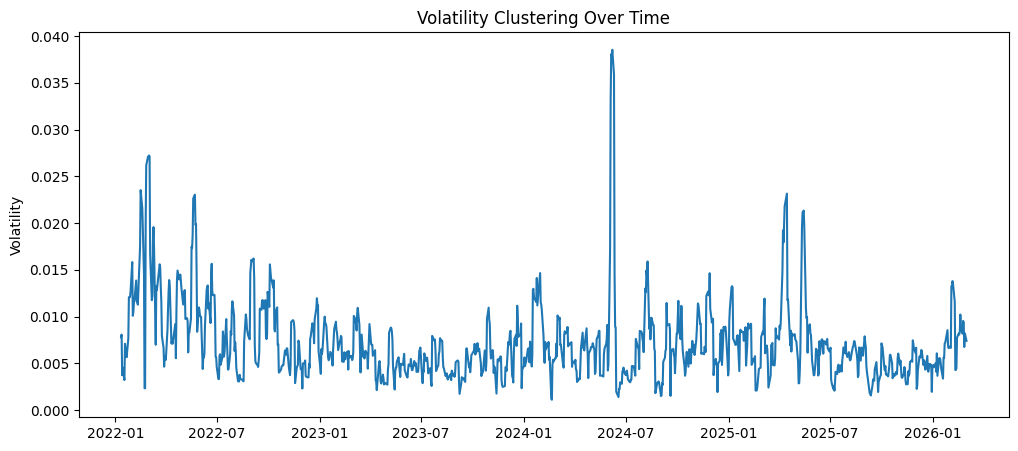

→ High-volatility periods tend to cluster together rather than appearing randomly.
→ Calm periods are followed by calm periods, and turbulent periods follow turbulence.
→ This is the core evidence of volatility clustering in financial markets.



In [40]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data['Realized Vol'])

plt.title("Volatility Clustering Over Time")
plt.ylabel("Volatility")

plt.show()

print("→ High-volatility periods tend to cluster together rather than appearing randomly.")
print("→ Calm periods are followed by calm periods, and turbulent periods follow turbulence.")
print("→ This is the core evidence of volatility clustering in financial markets.\n")